In [2]:
import os
from scipy.io import loadmat
import numpy as np
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E8.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
print("Tabla xCellLog: \n", xCellLog)


Tabla xCellLog: 
 [[[ -39.56824394   45.46941507   -4.5336295 ]
  [  59.41533752  -77.32954597   -9.24867091]
  [ 110.13940746   77.68399603   -4.65261754]
  ...
  [          nan           nan           nan]
  [          nan           nan           nan]
  [          nan           nan           nan]]

 [[ -40.72152014   44.86821965   -4.52998982]
  [  59.97768723  -77.06604552   -9.25623178]
  [ 109.22582665   77.6667053    -4.65965814]
  ...
  [          nan           nan           nan]
  [          nan           nan           nan]
  [          nan           nan           nan]]

 [[ -41.86503274   44.27436472   -4.52604227]
  [  60.54799432  -76.79237197   -9.26327888]
  [ 108.31941766   77.65514436   -4.66633221]
  ...
  [          nan           nan           nan]
  [          nan           nan           nan]
  [          nan           nan           nan]]

 ...

 [[-197.72830007 -109.14713585   -2.99828199]
  [ 149.71313316  -23.72963929   -8.67765562]
  [ -64.51921374   15.48734873  

In [3]:
xCellLog.shape

(187, 903, 3)

In [4]:
#Ahora ya tenemos todas las tablas, vamos a seleccionar un instante de tiempo en todas las tablas, por ejemplo tVec[0, 4]
tVec_t = tVec[0, 4] #En primer lugar seleccionamos el instante de tiempo con el que vamos a trabajar
#print("Tiempo con el que vamos a trabajar: \n", tVec_t)

IDLogs_t = IDLogs[4, :] #Nos quedamos con los IDLogs de ese instante de tiempo
IDLogs_t_notNans = IDLogs_t[~np.isnan(IDLogs_t)].astype(int) #Eliminamos los Nans ya que al trabajar en un único instante de tiempo no nos interesan
#print("IDLogs en el instante de tiempo 4 \n", IDLogs_t_notNans)

parentCell_t = parentCell[0, IDLogs_t_notNans] #Filtramos las partículas que tenemos en el instante de tiempo 4 ya que las demás no nos interesan
#print("parentCell en un instante de tiempo: \n", parentCell_t)

xCellLog_t = xCellLog[4, :, :] #Nos quedamos con las 3 coordenadas de los IDLogs que tenemos en el instante de tiempo t5
xCellLog_t_notNans = xCellLog_t[~np.isnan(xCellLog_t).any(axis=1)] #Quitamos los Nan
#print("xCellLog en el instante de tiempo t para las partículas que tenemos en ese instante", xCellLog_t_notNans)

In [5]:
#Vamos a comprobar las dimensiones de todas las tablas
print("Tamaño IDLogs_t sin Nans", IDLogs_t_notNans.shape)
print("Tamaño parentCell_t", parentCell_t.shape)
print("Tamaño xCellLog_t sin Nans", xCellLog_t_notNans.shape)

Tamaño IDLogs_t sin Nans (892,)
Tamaño parentCell_t (892,)
Tamaño xCellLog_t sin Nans (892, 3)


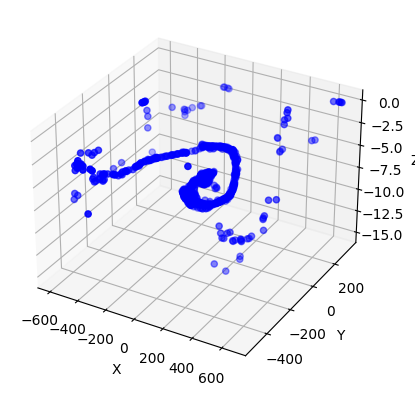

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Suponiendo que xCellLog_t_notNans es el array con la forma (602, 3)
# Aquí 'x', 'y', 'z' son las 3 coordenadas de cada punto en 3D.
x = xCellLog_t_notNans[:, 0]
y = xCellLog_t_notNans[:, 1]
z = xCellLog_t_notNans[:, 2]

# Crear una figura
fig = plt.figure()

# Crear un eje 3D
ax = fig.add_subplot(111, projection='3d')

# Crear un gráfico de dispersión (scatter plot) en 3D
ax.scatter(x, y, z, c='b', marker='o')

# Etiquetas de los ejes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#Habilita el poder moverlo
plt.ion()

# Mostrar el gráfico
plt.show()


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      2 |             - |             -
     2 |      200 |      3 |  0.000000E+00 |             f
     3 |      300 |      4 |  0.000000E+00 |             f
     4 |      400 |      2 |  0.1290322581 |         ideal
     5 |      500 |      3 |  0.4363636364 |         ideal
     6 |      600 |      3 |  0.0848484848 |             f
     7 |      700 |      3 |  0.0350877193 |         ideal
     8 |      800 |      3 |  0.5000000000 |         ideal
     9 |      900 |      3 |  0.2500000000 |         ideal
    10 |     1000 |      3 |  0.1489361702 |         ideal
    11 |     1100 |      3 |  0.0961538462 |         ideal
    12 |     1200 |      4 |  0.000000E+00 |             f
    13 |     1300 |      4 |  0.000000E+00 |             f
    14 |     1400 |      4 |  0.0370370370 |         ideal
    15 |     1500 |      3 |  0.1147540984 |         ideal
    16 |     1600 |      4 |  0.0895522388 |         ide

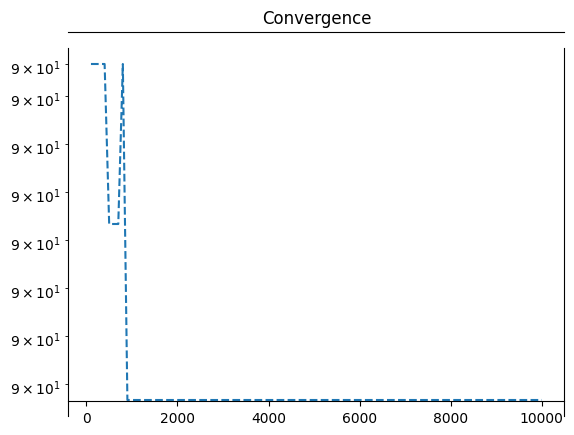

8


In [13]:
import numpy as np
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.core.sampling import Sampling
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling


# # === Muestreo personalizado ===
class CustomSampling(Sampling):
    def _do(self, problem, n_samples, **kwargs):
        samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        
        for i in range(n_samples):
            sample = []
            for j in range(0, problem.n_var, 3):  # Iterar en pasos de 3 (x, y, z)
                while True:  # Repetir hasta que la distancia mínima se cumpla
                    x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
                    y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
                    z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
                    nueva_particula = [x, y, z]
                    
                    # Comprobar la distancia mínima entre la nueva partícula y las anteriores
                    dist_violada = False
                    for k in range(0, len(sample), 3):  # Revisar distancias con las partículas previas
                        if calcular_distancia(nueva_particula, sample[k:k+3]) <= problem.rango_deteccion:
                            dist_violada = True
                            break
                    
                    # Si no se viola la condición de distancia mínima, se agrega
                    if not dist_violada:
                        sample.extend(nueva_particula)
                        break
            
            samples[i] = sample  # Guardar el individuo generado
        
        return samples

# # === Mutación personalizada ===
# class CustomMutation(Mutation):
#     def __init__(self, sigma=0.1, prob=0.2):
#         """
#         sigma: desviación estándar de la mutación (cuánto se altera cada coordenada).
#         prob: probabilidad de mutar cada coordenada.
#         """
#         super().__init__()
#         self.sigma = sigma
#         self.prob = prob

#     def _do(self, problem, X, **kwargs):
#         n_ind, n_var = X.shape  # Cantidad de individuos y variables

#         # Creamos una copia de los individuos
#         mutated_X = np.copy(X)

#         # Aplicamos mutación con probabilidad `self.prob`
#         mask = np.random.rand(n_ind, n_var) < self.prob
#         noise = np.random.randn(n_ind, n_var) * self.sigma  # Ruido gaussiano
#         mutated_X[mask] += noise[mask]  

#         return mutated_X

# # === Cruzamiento personalizado ===
# class CustomCrossover(Crossover):
#     def __init__(self):
#         # Definimos un crossover de dos padres con la misma cantidad de variables
#         super().__init__(2, 2)

#     def _do(self, problem, X, **kwargs):
#         n_offsprings, n_parents, n_var = X.shape  # Obtiene dimensiones

#         # Creamos un array para los hijos
#         offspring = np.full_like(X, np.nan)

#         # Realizamos un cruce en un punto aleatorio
#         for i in range(n_offsprings):
#             p1, p2 = X[i, 0], X[i, 1]  # Tomamos dos padres

#             # Seleccionamos un punto de corte en la cantidad de coordenadas
#             point = np.random.randint(1, n_var)  

#             # Generamos los hijos intercambiando segmentos
#             offspring[i, 0, :point] = p1[:point]
#             offspring[i, 0, point:] = p2[point:]

#             offspring[i, 1, :point] = p2[:point]
#             offspring[i, 1, point:] = p1[point:]

#         return offspring



# === Función para calcular la distancia Euclidiana en 3D ===
def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2+(p1[2]-p2[2])**2)
    
# === Función para eliminar partículas dentro del rango de detección ===
def eliminar_particulas_en_rango(mapa, centro, rango_deteccion):
    deteccion = 0
    indices_a_eliminar = []
    
    # Encontrar las partículas dentro del rango de detección
    for i, particula in enumerate(mapa):
        if calcular_distancia(particula, centro) <= rango_deteccion:
            indices_a_eliminar.append(i)
            deteccion += 1
            #if i == 1:
                #print(f"Posicion sonda: {centro}, posición partícula: {particula}, distancia: {calcular_distancia(particula,centro)}")
            
    # Eliminar las partículas detectadas (usando np.delete)
    mapa_actualizado = np.delete(mapa, indices_a_eliminar, axis=0)
    #print(f"shape del mapa que se está usando: {mapa_actualizado.shape}")
    #print(f"Partículas detectadas: {deteccion}")
    

    
    return mapa_actualizado, deteccion

# === Problema de optimización ===
class OptimizacionConDeteccion(ElementwiseProblem):
    def __init__(self, mapa_particulas, n_puntos=10, rango_deteccion=10, max_dist=1000):
        self.mapa_particulas = mapa_particulas  # Partículas en 3D
        self.rango_deteccion = rango_deteccion
        self.n_puntos = n_puntos
        self.max_dist = max_dist
        self.xl = np.array([-600, -400, -20])
        self.xu = np.array([600, 200, 0])
        # Definir el número de variables como el número de puntos de paso (n_puntos * 3 coordenadas)
        super().__init__(n_var=n_puntos*3 , n_obj=2, n_constr=0, xl=np.tile(self.xl, n_puntos), xu=np.tile(self.xu, n_puntos))

    def _evaluate(self, x, out, *args, **kwargs):
        # x contiene los índices de las partículas ordenadas para el recorrido
        recorrido = [x[i:i+3] for i in range(0, len(x), 3)]

        # Longitud total del recorrido
        longitud_recorrido = 0
        penalty = 0
        detecciones_totales = 0
        mapa_actualizado = self.mapa_particulas.copy()

        # Iterar sobre el recorrido y calcular la longitud total
        for i in range(len(recorrido) - 1):
            p1 = recorrido[i]
            p2 = recorrido[i + 1]
            longitud_recorrido += calcular_distancia(p1, p2)
            penalty +=  self.rango_deteccion - calcular_distancia(p1, p2)
            # Actualizar el mapa y contar las partículas detectadas
            mapa_actualizado, detecciones = eliminar_particulas_en_rango(mapa_actualizado, p1, self.rango_deteccion)
            detecciones_totales += detecciones
        #print(f"detecciones totales = {detecciones_totales}")
        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        out["F"] = [longitud_recorrido + penalty, -detecciones_totales]  # Usamos -detecciones_totales para maximizar

convergence = []

# Definir el callback para capturar la convergencia
def callback(algorithm):
    gen = algorithm.n_gen
    pop = algorithm.pop
    # Obtener la longitud total del recorrido (primer objetivo)
    convergence.append(pop.get("F")[:, 0])  # Almacenar el primer objetivo


# Crear el problema de optimización
problema = OptimizacionConDeteccion(xCellLog_t_notNans)

# Crear el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=100,
    #n_offsprings=10,
    # sampling=CustomSampling(),
    # crossover=CustomCrossover(),
    # mutation=CustomMutation(),
    sampling=CustomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(prob=0.2, eta=10),
    eliminate_duplicates=True
)

algorithm.callback = callback

# Ejecutar la optimización
result = minimize(
    problema,
    algorithm,
    termination=('n_gen', 100),
    seed=42,
    verbose=True,
    save_history=True
)

n_evals = np.array([e.evaluator.n_eval for e in result.history])
opt = np.array([e.opt[0].F for e in result.history])

plt.title("Convergence")
plt.plot(n_evals, opt, "--")
plt.yscale("log")
plt.show()

print(len(result.F))

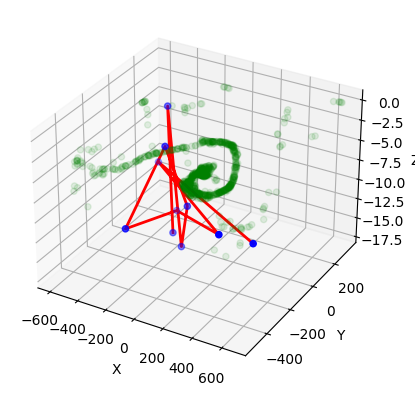

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

mejor_solucion = result.X[0]
x=[]
y=[]
z=[]

# Crear una figura
fig = plt.figure()

# Crear un eje 3D
ax = fig.add_subplot(111, projection='3d')

map_x = xCellLog_t_notNans[:, 0]
map_y = xCellLog_t_notNans[:, 1]
map_z = xCellLog_t_notNans[:, 2]

ax.scatter(map_x, map_y, map_z, c='green', marker='o', alpha=0.1)


for i in range(0, len(mejor_solucion), 3):
    x.append(mejor_solucion[i])
    y.append(mejor_solucion[i+1])
    z.append(mejor_solucion[i+2])

# Crear un gráfico de dispersión (scatter plot) en 3D
ax.scatter(x, y, z, c='b', marker='o')
ax.plot(x, y, z, c='r', linestyle='-', linewidth=2) 


# Etiquetas de los ejes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#Habilita el poder moverlo
plt.ion()

# Mostrar el gráfico
plt.show()

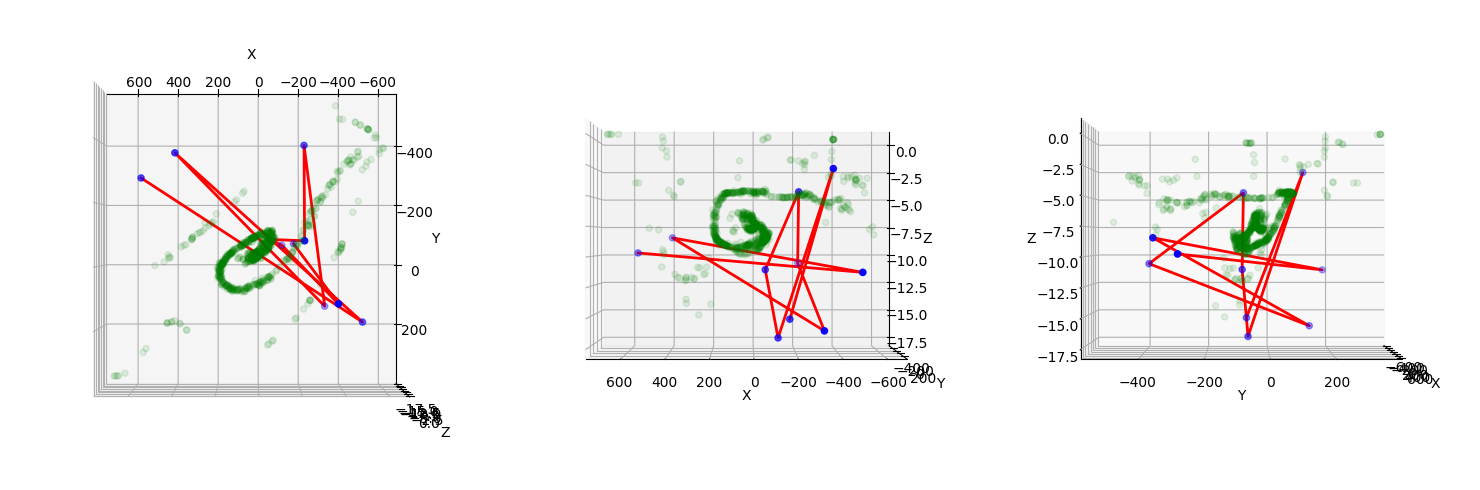

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Datos de ejemplo (reemplaza esto con tus propios datos)
mejor_solucion = result.X[0]
x = []
y = []
z = []

# Crear una figura
fig = plt.figure(figsize=(15, 5))

# Crear el primer subplot para la vista desde Z (alzado)
ax1 = fig.add_subplot(131, projection='3d')

map_x = xCellLog_t_notNans[:, 0]
map_y = xCellLog_t_notNans[:, 1]
map_z = xCellLog_t_notNans[:, 2]

ax1.scatter(map_x, map_y, map_z, c='green', marker='o', alpha=0.1)

for i in range(0, len(mejor_solucion), 3):
    x.append(mejor_solucion[i])
    y.append(mejor_solucion[i+1])
    z.append(mejor_solucion[i+2])

ax1.scatter(x, y, z, c='b', marker='o')
ax1.plot(x, y, z, c='r', linestyle='-', linewidth=2)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.view_init(elev=90, azim=90)  # Vista desde Z

# Crear el segundo subplot para la vista desde X (perfil lateral)
ax2 = fig.add_subplot(132, projection='3d')

ax2.scatter(map_x, map_y, map_z, c='green', marker='o', alpha=0.1)

ax2.scatter(x, y, z, c='b', marker='o')
ax2.plot(x, y, z, c='r', linestyle='-', linewidth=2)

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.view_init(elev=0, azim=90)  # Vista desde X (perfil lateral)

# Crear el tercer subplot para la vista desde Y (perfil frontal)
ax3 = fig.add_subplot(133, projection='3d')

ax3.scatter(map_x, map_y, map_z, c='green', marker='o', alpha=0.1)

ax3.scatter(x, y, z, c='b', marker='o')
ax3.plot(x, y, z, c='r', linestyle='-', linewidth=2)

ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.view_init(elev=0, azim=0)  # Vista desde Y (perfil frontal)

# Ajustar el espacio entre los subgráficos
plt.tight_layout()

# Mostrar el gráfico
plt.show()


In [16]:
dist_total=0
for i in range(len(x)-1):
    p1 = [x[i], y[i], z[i]]
    p2 = [x[i+1], y[i+1], z[i+1]]
    #print(calcular_distancia(p1, p2))
    dist_total+=calcular_distancia(p1, p2)
print(dist_total)

4774.5436003012455


In [11]:
tVec

array([[65.        , 65.01666667, 65.03333333, 65.05      , 65.06666667,
        65.08333333, 65.1       , 65.11666667, 65.13333333, 65.15      ,
        65.16666667, 65.18333333, 65.2       , 65.21666667, 65.23333333,
        65.25      , 65.26666667, 65.28333333, 65.3       , 65.31666667,
        65.33333333, 65.35      , 65.36666667, 65.38333333, 65.4       ,
        65.41666667, 65.43333333, 65.45      , 65.46666667, 65.48333333,
        65.5       , 65.51666667, 65.53333333, 65.55      , 65.56666667,
        65.58333333, 65.6       , 65.61666667, 65.63333333, 65.65      ,
        65.66666667, 65.68333333, 65.7       , 65.71666667, 65.73333333,
        65.75      , 65.76666667, 65.78333333, 65.8       , 65.81666667,
        65.83333333, 65.85      , 65.86666667, 65.88333333, 65.9       ,
        65.91666667, 65.93333333, 65.95      , 65.96666667, 65.98333333,
        66.        , 66.01666667, 66.03333333, 66.05      , 66.06666667,
        66.08333333, 66.1       , 66.11666667, 66.1

In [138]:
len(xCellLog)

187

In [3]:
result.X

NameError: name 'result' is not defined